# Shape reward vs. molecular similarity

The **shape** reward in `rl/rewards.py` is **USRCAT similarity × Morgan Tanimoto** against a fixed reference (**Prilocaine**, `_SHAPE_REF_SMILES`).

This notebook embeds a few SMILES with the same conformer search as the reference, scores them with `_score_shape_single`, and shows structures with **py3Dmol** (same stack as the notebooks under `../notebooks/`, e.g. `visualize_interpolation.ipynb` / `check_mcs.ipynb`).

In [26]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def find_chemflow_root() -> Path:
    """Locate repo root (directory containing rl/rewards.py)."""
    env = os.environ.get("CHEMFLOW_ROOT")
    if env:
        p = Path(env).expanduser().resolve()
        if (p / "rl" / "rewards.py").is_file():
            return p

    candidates: list[Path] = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.extend(cwd.parents)
    for rel in (
        Path("shape_reward_similarity.ipynb"),
        Path("rl/experiments/shape/shape_reward_similarity.ipynb"),
    ):
        p = (cwd / rel).resolve()
        if p.is_file():
            candidates.append(p.parent)
            candidates.extend(p.parents)

    seen: set[Path] = set()
    for start in candidates:
        if start in seen:
            continue
        seen.add(start)
        base = start
        for _ in range(40):
            if (base / "rl" / "rewards.py").is_file():
                return base
            if base == base.parent:
                break
            base = base.parent
    raise RuntimeError(
        "Could not find chemflow repo (rl/rewards.py). "
        "cd into the repo, open the notebook from rl/experiments/shape/, or set CHEMFLOW_ROOT."
    )


ROOT = find_chemflow_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("PROJECT_ROOT", str(ROOT))

import pandas as pd
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

from rl.rewards import _SHAPE_REF_SMILES, _get_shape_ref, _score_shape_single

In [27]:
def embed_best_conformer(mol: Chem.Mol) -> Chem.Mol | None:
    """Match `rl.rewards` `_get_shape_ref`: ETKDGv3, MMFF pick lowest energy."""
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    cids = AllChem.EmbedMultipleConfs(mol, numConfs=50, params=params)
    if not len(cids):
        return None
    best_e, best_cid = float("inf"), -1
    for cid in cids:
        AllChem.MMFFOptimizeMolecule(mol, confId=cid, maxIters=2000)
        mp = AllChem.MMFFGetMoleculeProperties(mol)
        ff = AllChem.MMFFGetMoleculeForceField(mol, mp, confId=cid)
        if ff is not None and ff.CalcEnergy() < best_e:
            best_e, best_cid = ff.CalcEnergy(), cid
    for cid in [c.GetId() for c in mol.GetConformers() if c.GetId() != best_cid]:
        mol.RemoveConformer(cid)
    return mol


def mol_from_smiles(smiles: str) -> Chem.Mol | None:
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    m = Chem.AddHs(m)
    return embed_best_conformer(m)

## Curated examples (roughly decreasing reward)

Order is chosen so **shape product** (USR × Tanimoto) decreases down the table; exact numbers depend on the stochastic embed + MMFF optimum.

In [28]:
# Warm reference cache (builds Prilocaine + descriptors)
_get_shape_ref()

ROWS = [
    ("Reference (Prilocaine)", _SHAPE_REF_SMILES),
    ("Same scaffold, minus ring methyl", "CCCNC(C)C(=O)Nc1ccccc1"),
    ("Aryl regioisomer of ref", "CCCNC(C)C(=O)Nc1ccc(C)cc1C"),
    ("Lidocaine (related local anesthetic)", "CCN(CC)C(=O)Cc1ccccc1"),
    ("Ibuprofen", "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Benzene", "c1ccccc1"),
]

records = []
mols = []
for label, smi in ROWS:
    m = mol_from_smiles(smi)
    mols.append((label, smi, m))
    if m is None or m.GetNumConformers() == 0:
        records.append({"name": label, "smiles": smi, "usr": None, "tanimoto": None, "product": None})
        continue
    usr, tani, prod = _score_shape_single(m)
    records.append(
        {"name": label, "smiles": smi, "usr": usr, "tanimoto": tani, "product": prod}
    )

df = pd.DataFrame(records)
display(df)

,name,smiles,usr,tanimoto,product
0,Reference (Prilocaine),CCCNC(C)C(=O)Nc1ccccc1C,1.000000,1.000000,1.000000
1,"Same scaffold, minus ring methyl",CCCNC(C)C(=O)Nc1ccccc1,0.522933,0.711111,0.371864
2,Aryl regioisomer of ref,CCCNC(C)C(=O)Nc1ccc(C)cc1C,0.372965,0.755102,0.281627
3,Lidocaine (related local anesthetic),CCN(CC)C(=O)Cc1ccccc1,0.231654,0.254545,0.058966
4,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,0.168647,0.254237,0.042876
5,Benzene,c1ccccc1,0.125556,0.071429,0.008968


## 3D views (py3Dmol)

Same styling pattern as `notebooks/check_mcs.ipynb`: sticks + small spheres.

In [29]:
width, height = 800, 400

for label, smi, m in mols:
    print(label, "|", smi)
    if m is None or m.GetNumConformers() == 0:
        print("  (embed failed)")
        continue
    view = py3Dmol.view(width=width, height=height)
    view.addModel(Chem.MolToMolBlock(m), "mol")
    view.setStyle({"stick": {"radius": 0.15}, "sphere": {"scale": 0.2}})
    view.zoomTo()
    view.show()

Reference (Prilocaine) | CCCNC(C)C(=O)Nc1ccccc1C


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Same scaffold, minus ring methyl | CCCNC(C)C(=O)Nc1ccccc1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Aryl regioisomer of ref | CCCNC(C)C(=O)Nc1ccc(C)cc1C


...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Ibuprofen | CC(C)Cc1ccc(cc1)C(C)C(=O)O


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Benzene | c1ccccc1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## GRPO shape checkpoint vs. base (pretrained) distribution

**Generate samples with a script** (recommended; avoids Lightning/Jupyter strategy issues):

    cd /path/to/chemflow
    python -m rl.experiments.shape.generate_shape_grpo_samples

Writes ``rl/experiments/shape/<rl_ckpt_stem>/shape_grpo_samples.pt`` with pretrained vs RL trajectories and vocab tokens. Use ``--n_mols``, ``--rl_ckpt``, ``--out``, or trailing Hydra overrides as needed.

**Notebook:** the cells below ``torch.load`` that file, score finals with ``_score_shape_single``, plot base vs RL, and py3Dmol top RL structures vs Prilocaine. You still need ``mol_from_smiles`` from earlier. **Reference vlines/scatter stars** reuse the curated table ``df`` when you ran that cell first with the same SMILES order—otherwise references are re-embedded and can differ slightly from the table. Set ``SHAPE_SAMPLES_PT`` in the imports cell if the artifact path differs.

The first code cell in this section sets ``PROJECT_ROOT`` and ``sys.path``. Set ``CHEMFLOW_ROOT`` if repo discovery fails.


In [30]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def find_chemflow_root() -> Path:
    """Locate repo root (directory containing rl/rewards.py)."""
    env = os.environ.get("CHEMFLOW_ROOT")
    if env:
        p = Path(env).expanduser().resolve()
        if (p / "rl" / "rewards.py").is_file():
            return p

    candidates: list[Path] = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.extend(cwd.parents)
    for rel in (
        Path("shape_reward_similarity.ipynb"),
        Path("rl/experiments/shape/shape_reward_similarity.ipynb"),
    ):
        p = (cwd / rel).resolve()
        if p.is_file():
            candidates.append(p.parent)
            candidates.extend(p.parents)

    seen: set[Path] = set()
    for start in candidates:
        if start in seen:
            continue
        seen.add(start)
        base = start
        for _ in range(40):
            if (base / "rl" / "rewards.py").is_file():
                return base
            if base == base.parent:
                break
            base = base.parent
    raise RuntimeError(
        "Could not find chemflow repo (rl/rewards.py). "
        "cd into the repo, open the notebook from rl/experiments/shape/, or set CHEMFLOW_ROOT."
    )


ROOT = find_chemflow_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("PROJECT_ROOT", str(ROOT))


'/network/scratch/g/goldszaa/chemflow'

In [31]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3Dmol
import torch
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import AllChem

from rl.rewards import _SHAPE_REF_SMILES, _get_shape_ref, _score_shape_single

# Output from: python -m rl.experiments.shape.generate_shape_grpo_samples
_RL_STEM = "grpo_shape_seed0_sig0p05_g1_mu2_kl0.05_lr1e-4_maxa60_omitposkl_best"
SHAPE_SAMPLES_PT = ROOT / "rl" / "experiments" / "shape" / _RL_STEM / "shape_grpo_samples.pt"

REF_ROWS = [
    ("Reference (Prilocaine)", _SHAPE_REF_SMILES),
    ("Same scaffold, minus ring methyl", "CCCNC(C)C(=O)Nc1ccccc1"),
    ("Aryl regioisomer of ref", "CCCNC(C)C(=O)Nc1ccc(C)cc1C"),
    ("Lidocaine (related local anesthetic)", "CCN(CC)C(=O)Cc1ccccc1"),
    ("Ibuprofen", "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Benzene", "c1ccccc1"),
]

colors = {"base": "#9e9e9e", "rl": "#1f77b4"}


def _score_traj_final(traj, vocab) -> tuple[float, float, float] | None:
    rd = traj[-1].to_rdkit_mol(vocab.atom_tokens, vocab.edge_tokens, vocab.charge_tokens)
    if rd is None or rd.GetNumConformers() == 0:
        return None
    return _score_shape_single(rd)


def molblock_shift_x(mol: Chem.Mol, dx: float) -> str:
    m = Chem.Mol(mol)
    conf = m.GetConformer()
    for i in range(m.GetNumAtoms()):
        p = conf.GetAtomPosition(i)
        conf.SetAtomPosition(i, Chem.rdGeometry.Point3D(p.x + dx, p.y, p.z))
    return Chem.MolToMolBlock(m)


def mol_for_py3d(mol: Chem.Mol, *, mmff_relax: bool = True) -> Chem.Mol:
    """Copy + optional MMFF — **display only**. Scores use raw `to_rdkit_mol` coords."""
    m = Chem.Mol(mol)
    if mmff_relax and m.GetNumConformers() > 0:
        try:
            AllChem.MMFFOptimizeMolecule(m, confId=0, maxIters=500)
        except Exception:
            pass
    return m


PY3D_RL_MMFF_RELAX = True  # False = exact trajectory coords (often ugly); True = MMFF for display only


In [32]:
_get_shape_ref()

try:
    bundle = torch.load(SHAPE_SAMPLES_PT, map_location="cpu", weights_only=False)
except TypeError:
    bundle = torch.load(SHAPE_SAMPLES_PT, map_location="cpu")

meta = bundle["meta"]
vocab = SimpleNamespace(**bundle["vocab"])
N_MOLS = int(meta["n_mols_requested"])
valid_base = bundle["base"]["valid_mols"]
valid_rl = bundle["rl"]["valid_mols"]
inv_base = bundle["base"].get("invalid_mols", [])
inv_rl = bundle["rl"].get("invalid_mols", [])
print(
    f"loaded {SHAPE_SAMPLES_PT.resolve()} | requested ≤{N_MOLS} mols per model | "
    f"base valid {len(valid_base)} invalid {len(inv_base)} | "
    f"rl valid {len(valid_rl)} invalid {len(inv_rl)}"
)


loaded /network/scratch/g/goldszaa/chemflow/rl/experiments/shape/grpo_shape_seed0_sig0p05_g1_mu2_kl0.05_lr1e-4_maxa60_omitposkl_best/shape_grpo_samples.pt | requested ≤100 mols per model | base valid 100 invalid 0 | rl valid 100 invalid 0


In [33]:
records: list[dict] = []
for tag, trajs in [("base", valid_base), ("rl", valid_rl)]:
    for traj in trajs:
        sc = _score_traj_final(traj, vocab)
        if sc is None:
            continue
        u, t, p = sc
        rd = traj[-1].to_rdkit_mol(vocab.atom_tokens, vocab.edge_tokens, vocab.charge_tokens)
        smi = Chem.MolToSmiles(rd, canonical=True) if rd is not None else ""
        row = {"distrib": tag, "usr": u, "tanimoto": t, "product": p, "smiles": smi}
        if tag == "rl":
            row["traj"] = traj
        records.append(row)

gen_df = pd.DataFrame([{k: v for k, v in r.items() if k != "traj"} for r in records])
print(
    f"scored valid: base {(gen_df['distrib']=='base').sum()} | rl {(gen_df['distrib']=='rl').sum()}"
)
display(gen_df.groupby("distrib")[["usr", "tanimoto", "product"]].agg(["mean", "std", "median"]))

# Curated reference markers: prefer the table from the first section (`df`) so plot vlines/scatter
# match the HTML table exactly (same embedded conformers). Otherwise re-embed here.
if (
    "df" in globals()
    and isinstance(df, pd.DataFrame)
    and {"name", "smiles", "usr", "tanimoto", "product"}.issubset(df.columns)
    and len(df) == len(REF_ROWS)
    and all(df.iloc[i]["smiles"] == REF_ROWS[i][1] for i in range(len(REF_ROWS)))
):
    ref_df = df[["name", "usr", "tanimoto", "product"]].copy()
    print("ref markers: reused curated table `df` (same numbers as above)")
else:
    ref_scores = []
    for label, smi in REF_ROWS:
        m = mol_from_smiles(smi)
        if m is None or m.GetNumConformers() == 0:
            ref_scores.append({"name": label, "usr": np.nan, "tanimoto": np.nan, "product": np.nan})
            continue
        u, t, p = _score_shape_single(m)
        ref_scores.append({"name": label, "usr": u, "tanimoto": t, "product": p})
    ref_df = pd.DataFrame(ref_scores)
    print("ref markers: recomputed with mol_from_smiles (run the curated table cell first to match it exactly)")


scored valid: base 100 | rl 100


usr                      tanimoto                       product  \
             mean       std    median      mean       std    median      mean   
distrib                                                                         
base     0.138477  0.016623  0.135215  0.088245  0.043798  0.080645  0.012517   
rl       0.276088  0.006360  0.275352  0.319266  0.013329  0.326923  0.088126   

                             
              std    median  
distrib                      
base     0.006966  0.011076  
rl       0.003737  0.089786

ref markers: reused curated table `df` (same numbers as above)


In [37]:
# Diversity: unique SMILES vs duplicates (helps distinguish tight ref-matching band vs mode collapse)
for tag in sorted(gen_df["distrib"].unique()):
    smi = gen_df.loc[gen_df["distrib"] == tag, "smiles"]
    n = len(smi)
    nu = smi.nunique()
    dup = (1.0 - nu / n) if n else 0.0
    print(f"{tag}: n={n} | unique SMILES={nu} | duplicate share={dup:.1%}")
    display(smi.value_counts().head(10))

base: n=100 | unique SMILES=100 | duplicate share=0.0%


smiles
[H]C([H])([H])C1([H])OC12C([H])([H])C([H])([H])C1([H])C([H])([H])C12[H]    1
[H]C1=C([H])C2([H])C([H])([H])C(C#N)(C1([H])[H])C2([H])[H]                 1
[H]C1(C#N)C(=O)N2C([H])([H])C21[H]                                         1
[H]C1([H])OC([H])([H])C2([H])C([H])(C#N)C([H])([H])C12[H]                  1
[H]ON=C(C(=O)C([H])([H])O[H])C([H])([H])C([H])([H])[H]                     1
[H]C#CC([H])([H])C([H])([H])C(=O)C([H])(O[H])C([H])([H])[H]                1
[H]C1([H])C2([H])OC1([H])C([H])([H])C1(C([H])([H])C1([H])[H])C2([H])[H]    1
[H]C1=C([H])C([H])([H])C2([H])C([H])(C([H])([H])[H])OC2([H])C1([H])[H]     1
[H]C([H])([H])C12C([H])([H])N3C([H])([H])C([H])(C1([H])[H])C32[H]          1
[H]N1C2([H])C([H])(OC([H])([H])[H])C([H])(C([H])([H])[H])C12[H]            1
Name: count, dtype: int64

rl: n=100 | unique SMILES=2 | duplicate share=98.0%


smiles
[H]c1oc(N([H])C([H])([H])C([H])([H])C([H])([H])[H])c([H])c1[H]         75
[H]c1c([H])c(N([H])C([H])([H])C([H])([H])C([H])([H])[H])n([H])c1[H]    25
Name: count, dtype: int64

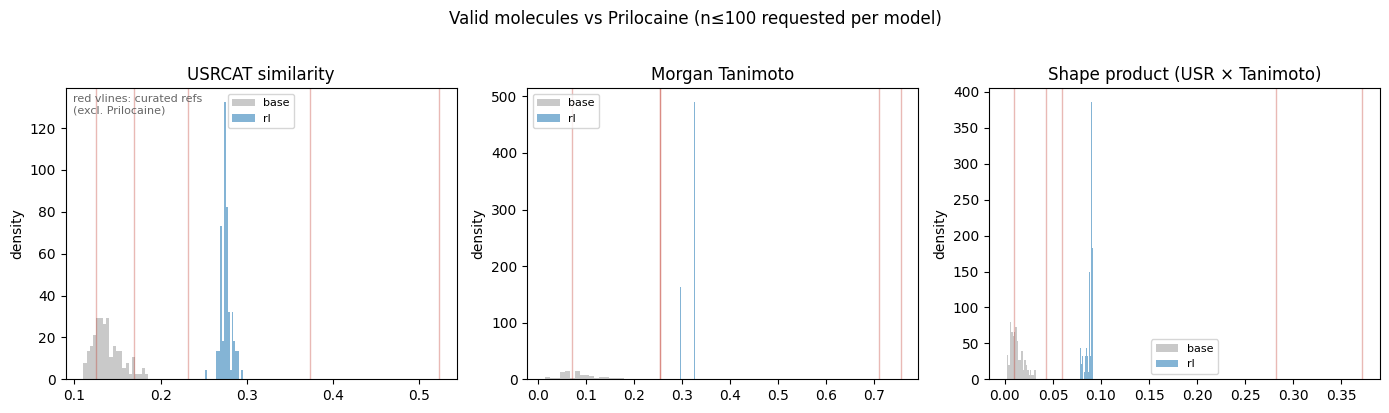

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, title in zip(
    axes,
    ["usr", "tanimoto", "product"],
    ["USRCAT similarity", "Morgan Tanimoto", "Shape product (USR × Tanimoto)"],
):
    for tag in ["base", "rl"]:
        s = gen_df.loc[gen_df["distrib"] == tag, key]
        if len(s) == 0:
            continue
        ax.hist(s, bins=20, alpha=0.55, color=colors[tag], label=tag, density=True)
    for _, row in ref_df.iterrows():
        if row["name"].startswith("Reference"):
            continue
        if np.isfinite(row[key]):
            ax.axvline(row[key], color="#c0392b", alpha=0.35, linewidth=1.0)
    ax.set_title(title)
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
axes[0].text(
    0.02,
    0.98,
    "red vlines: curated refs\n(excl. Prilocaine)",
    transform=axes[0].transAxes,
    va="top",
    fontsize=8,
    color="#666",
)
fig.suptitle(f"Valid molecules vs Prilocaine (n≤{N_MOLS} requested per model)", y=1.02)
fig.tight_layout()
plt.show()


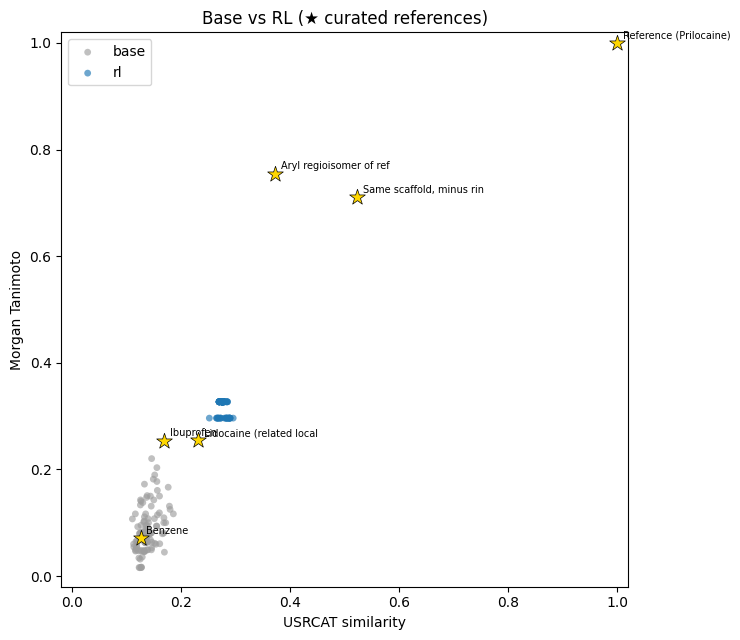

In [35]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for tag, c in colors.items():
    sub = gen_df[gen_df["distrib"] == tag]
    ax.scatter(sub["usr"], sub["tanimoto"], c=c, s=24, alpha=0.65, label=tag, edgecolors="none")
for _, row in ref_df.iterrows():
    if not np.isfinite(row["usr"]):
        continue
    ax.scatter(
        row["usr"],
        row["tanimoto"],
        marker="*",
        s=140,
        c="gold",
        edgecolors="black",
        linewidths=0.5,
        zorder=5,
    )
    ax.annotate(
        str(row["name"])[:24],
        (row["usr"], row["tanimoto"]),
        fontsize=7,
        xytext=(4, 3),
        textcoords="offset points",
    )
ax.set_xlabel("USRCAT similarity")
ax.set_ylabel("Morgan Tanimoto")
ax.set_title("Base vs RL (★ curated references)")
ax.legend()
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
plt.show()


In [36]:
target_mol = mol_from_smiles(_SHAPE_REF_SMILES)
assert target_mol is not None

rl_scored = [r for r in records if r["distrib"] == "rl" and "traj" in r]
rl_scored.sort(key=lambda r: r["product"], reverse=True)
top_k = min(10, len(rl_scored))
print(
    f"Top {top_k} RL by shape product — green=Prilocaine (ETKDG/MMFF), cyan=RL final. "
    f"RL geometry: {'MMFF-relaxed for display' if PY3D_RL_MMFF_RELAX else 'raw model coords'}."
)
sep = 14.0
width, height = 950, 420
for rank, row in enumerate(rl_scored[:top_k], start=1):
    traj = row["traj"]
    rd = traj[-1].to_rdkit_mol(
        vocab.atom_tokens,
        vocab.edge_tokens,
        vocab.charge_tokens,
    )
    if rd is None:
        continue
    rd_view = mol_for_py3d(rd, mmff_relax=PY3D_RL_MMFF_RELAX)
    print(
        f"  #{rank} product={row['product']:.4f} | usr={row['usr']:.3f} tani={row['tanimoto']:.3f} | {row['smiles']}"
    )
    view = py3Dmol.view(width=width, height=height)
    view.addModel(Chem.MolToMolBlock(target_mol), "mol")
    view.addModel(molblock_shift_x(rd_view, sep), "mol")
    for mid, scheme in [(0, "greenCarbon"), (1, "cyanCarbon")]:
        view.setStyle(
            {"model": mid},
            {"stick": {"radius": 0.15, "colorscheme": scheme}, "sphere": {"scale": 0.2, "colorscheme": scheme}},
        )
    view.zoomTo()
    view.show()


Top 10 RL by shape product — green=Prilocaine (ETKDG/MMFF), cyan=RL final. RL geometry: MMFF-relaxed for display.
  #1 product=0.0932 | usr=0.285 tani=0.327 | [H]c1oc(N([H])C([H])([H])C([H])([H])C([H])([H])[H])c([H])c1[H]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  #2 product=0.0930 | usr=0.285 tani=0.327 | [H]c1oc(N([H])C([H])([H])C([H])([H])C([H])([H])[H])c([H])c1[H]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  #3 product=0.0930 | usr=0.284 tani=0.327 | [H]c1oc(N([H])C([H])([H])C([H])([H])C([H])([H])[H])c([H])c1[H]


...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  #9 product=0.0911 | usr=0.279 tani=0.327 | [H]c1oc(N([H])C([H])([H])C([H])([H])C([H])([H])[H])c([H])c1[H]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  #10 product=0.0910 | usr=0.278 tani=0.327 | [H]c1oc(N([H])C([H])([H])C([H])([H])C([H])([H])[H])c([H])c1[H]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.